# AQG Dataset Validation — Comprehensive Quality Check

Notebook ini melakukan validasi 2-level pada dataset AQG:

**Level 1: Per-Module Validation** (`dataset_aqg/output_modul/`)
- Quality check per modul
- Deteksi masalah early
- Identifikasi modul yang perlu re-generate

**Level 2: Final Dataset Validation** (`dataset_aqg/dataset-task-spesifc/`)
- Validasi dataset gabungan
- HuggingFace compatibility test
- Cross-module analysis
- Final decision: siap fine-tuning atau tidak?

---

## Setup

In [2]:
import sys, os, json
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

# Setup project root
project_root = Path(os.getcwd())
if project_root.name == 'pipeline':
    project_root = project_root.parent.parent
elif project_root.name == 'src':
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')
print(f'Python: {sys.version.split()[0]}')

# Paths
OUTPUT_MODUL = project_root / 'dataset_aqg' / 'output_modul'
FINAL_DATASET = project_root / 'dataset_aqg' / 'dataset-task-spesifc'

print(f'\nOutput modul: {OUTPUT_MODUL}')
print(f'Final dataset: {FINAL_DATASET}')
print(f'\nOutput modul exists: {OUTPUT_MODUL.exists()}')
print(f'Final dataset exists: {FINAL_DATASET.exists()}')

Project root: d:\2-Project\AQG
Python: 3.12.13

Output modul: d:\2-Project\AQG\dataset_aqg\output_modul
Final dataset: d:\2-Project\AQG\dataset_aqg\dataset-task-spesifc

Output modul exists: True
Final dataset exists: True


---

## Level 1: Per-Module Validation

Validasi setiap modul di `output_modul/` untuk deteksi masalah early.

In [3]:
def load_module_data(module_path: Path) -> List[dict]:
    """Load accumulated.jsonl dari satu modul"""
    acc_file = module_path / 'accumulated.jsonl'
    if not acc_file.exists():
        return []
    
    data = []
    with open(acc_file, encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def validate_module(module_name: str, data: List[dict]) -> dict:
    """Validasi satu modul, return metrics"""
    n = len(data)
    if n == 0:
        return {
            'name': module_name,
            'total': 0,
            'status': 'EMPTY',
            'issues': ['No data found']
        }
    
    # Hitung distribusi
    diff = Counter(d['metadata'].get('difficulty', 'unknown') for d in data)
    qtype = Counter(d['metadata'].get('question_type', 'unknown') for d in data)
    concepts = Counter(d['metadata'].get('concept', 'unknown') for d in data)
    
    # Hitung validation metrics
    validated = sum(1 for d in data if d['metadata'].get('validated') is True)
    has_tags = sum(1 for d in data if d['metadata'].get('misconception_tags'))
    
    # Hitung imbalance ratio
    diff_vals = [diff.get(k, 0) for k in ['easy', 'medium', 'hard']]
    nonzero = [v for v in diff_vals if v > 0]
    imbalance = round(max(nonzero) / min(nonzero), 2) if len(nonzero) > 1 else float('inf')
    
    # Deteksi issues
    issues = []
    if validated / n < 0.90:
        issues.append(f'Low validation rate: {validated/n*100:.1f}%')
    if has_tags / n < 0.90:
        issues.append(f'Low misconception tags coverage: {has_tags/n*100:.1f}%')
    if imbalance > 2.0:
        issues.append(f'Imbalanced difficulty: ratio={imbalance}x')
    if len(concepts) < 3:
        issues.append(f'Low concept diversity: only {len(concepts)} concepts')
    
    status = 'OK' if not issues else 'WARNING'
    
    return {
        'name': module_name,
        'total': n,
        'difficulty': dict(diff),
        'question_type': dict(qtype),
        'validated': validated,
        'validated_pct': round(validated / n * 100, 1),
        'has_tags': has_tags,
        'tags_pct': round(has_tags / n * 100, 1),
        'concepts': dict(concepts),
        'concept_count': len(concepts),
        'imbalance_ratio': imbalance,
        'status': status,
        'issues': issues
    }

# Load dan validasi semua modul
print('Loading modules...')
module_reports = {}

if OUTPUT_MODUL.exists():
    for module_dir in sorted(OUTPUT_MODUL.iterdir()):
        if module_dir.is_dir():
            data = load_module_data(module_dir)
            report = validate_module(module_dir.name, data)
            module_reports[module_dir.name] = report
            print(f'  ✓ {module_dir.name}: {report["total"]} data points')
else:
    print(f'⚠️  Output modul tidak ditemukan: {OUTPUT_MODUL}')

print(f'\nTotal modules loaded: {len(module_reports)}')

Loading modules...
  ✓ 01-Berkenalan-dengan-python: 90 data points
  ✓ 02-berinteraksi-dengan-data: 180 data points
  ✓ 03-ekspresi: 117 data points
  ✓ 04-aksi-sekuensial: 95 data points
  ✓ 05-control-flow: 118 data points
  ✓ 06-array: 126 data points
  ✓ 07-matriks: 100 data points
  ✓ 08-subprogram: 108 data points
  ✓ 09-oop: 148 data points
  ✓ 10-style-guide: 120 data points
  ✓ 11-unit-testing: 60 data points

Total modules loaded: 11


### Level 1 Summary: Per-Module Report

In [4]:
# Print summary table
if module_reports:
    print(f"\n{'='*100}")
    print(f"{'Modul':<45} {'Total':>6} {'Easy':>6} {'Med':>5} {'Hard':>5} {'Ratio':>7} {'Val%':>6} {'Tags%':>6} {'Status'}")
    print('='*100)
    
    total_data = 0
    ok_count = 0
    warning_count = 0
    
    for name, report in module_reports.items():
        if report['total'] == 0:
            print(f"{name:<45} {'EMPTY':>6}")
            continue
        
        total_data += report['total']
        d = report['difficulty']
        status_icon = '✓' if report['status'] == 'OK' else '⚠️'
        
        if report['status'] == 'OK':
            ok_count += 1
        else:
            warning_count += 1
        
        print(f"{name:<45} {report['total']:>6} {d.get('easy',0):>6} {d.get('medium',0):>5} {d.get('hard',0):>5} "
              f"{report['imbalance_ratio']:>7.2f} {report['validated_pct']:>5.1f}% {report['tags_pct']:>5.1f}%  {status_icon} {report['status']}")
    
    print('='*100)
    print(f"\nSummary:")
    print(f"  Total modules: {len(module_reports)}")
    print(f"  Total data points: {total_data}")
    print(f"  ✓ OK: {ok_count} modules")
    print(f"  ⚠️  WARNING: {warning_count} modules")
    
    # Print issues
    print(f"\nModules with issues:")
    has_issues = False
    for name, report in module_reports.items():
        if report['issues']:
            has_issues = True
            print(f"\n  ⚠️  {name}:")
            for issue in report['issues']:
                print(f"      - {issue}")
    
    if not has_issues:
        print("  ✓ No issues found!")
else:
    print("No module reports available.")


Modul                                          Total   Easy   Med  Hard   Ratio   Val%  Tags% Status
01-Berkenalan-dengan-python                       90     30    30    30    1.00 100.0% 100.0%  ✓ OK
02-berinteraksi-dengan-data                      180     60    60    60    1.00 100.0% 100.0%  ✓ OK
03-ekspresi                                      117     39    39    39    1.00 100.0% 100.0%  ✓ OK
04-aksi-sekuensial                                95     31    32    32    1.03 100.0% 100.0%  ✓ OK
05-control-flow                                  118     39    39    40    1.03 100.0% 100.0%  ✓ OK
06-array                                         126     42    42    42    1.00 100.0% 100.0%  ✓ OK
07-matriks                                       100     33    34    33    1.03 100.0% 100.0%  ✓ OK
08-subprogram                                    108     36    36    36    1.00 100.0% 100.0%  ✓ OK
09-oop                                           148     49    49    50    1.02 100.0% 100.0%  ✓ O

### Level 1 Visualization: Per-Module Graphs

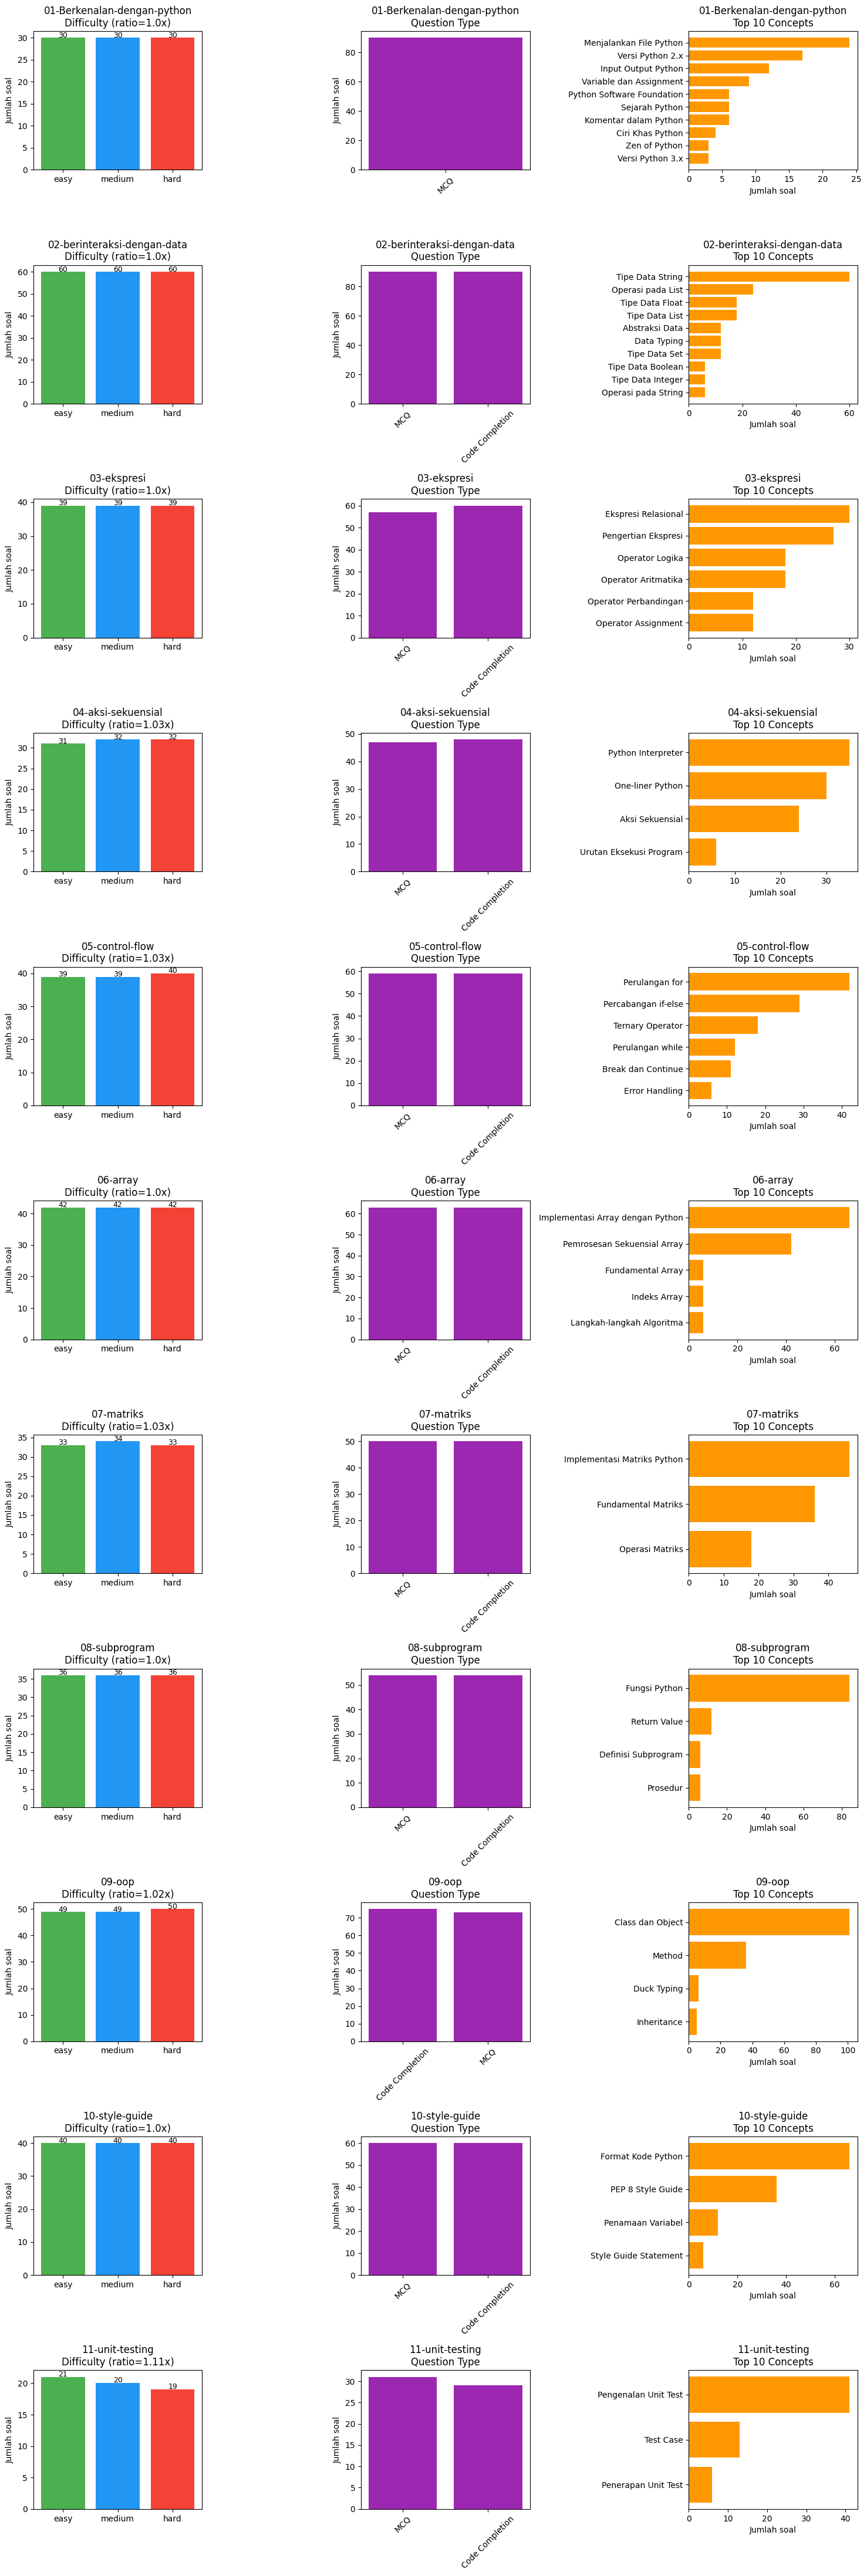


Grafik disimpan ke d:\2-Project\AQG\dataset_aqg\output_modul\validation_per_module.png


In [5]:
# Visualisasi per modul
if module_reports:
    n_mods = len([r for r in module_reports.values() if r['total'] > 0])
    if n_mods > 0:
        fig, axes = plt.subplots(n_mods, 3, figsize=(15, 4 * n_mods))
        if n_mods == 1:
            axes = [axes]
        
        row = 0
        for name, report in module_reports.items():
            if report['total'] == 0:
                continue
            
            short = name[:35]
            
            # Difficulty distribution
            ax = axes[row][0]
            keys = ['easy', 'medium', 'hard']
            vals = [report['difficulty'].get(k, 0) for k in keys]
            bars = ax.bar(keys, vals, color=['#4CAF50', '#2196F3', '#F44336'])
            ax.set_title(f'{short}\nDifficulty (ratio={report["imbalance_ratio"]}x)')
            ax.set_ylabel('Jumlah soal')
            for b, v in zip(bars, vals):
                if v > 0:
                    ax.text(b.get_x() + b.get_width()/2, v + 0.1, str(v), ha='center', fontsize=9)
            
            # Question type distribution
            ax = axes[row][1]
            qt = report['question_type']
            ax.bar(list(qt.keys()), list(qt.values()), color='#9C27B0')
            ax.set_title(f'{short}\nQuestion Type')
            ax.set_ylabel('Jumlah soal')
            ax.tick_params(axis='x', rotation=45)
            
            # Top concepts
            ax = axes[row][2]
            concepts = Counter(report['concepts'])
            top10 = concepts.most_common(10)
            if top10:
                labels, counts = zip(*top10)
                ax.barh(list(labels)[::-1], list(counts)[::-1], color='#FF9800')
                ax.set_title(f'{short}\nTop 10 Concepts')
                ax.set_xlabel('Jumlah soal')
            
            row += 1
        
        plt.tight_layout()
        out_png = OUTPUT_MODUL / 'validation_per_module.png'
        plt.savefig(str(out_png), dpi=120, bbox_inches='tight')
        plt.show()
        print(f'\nGrafik disimpan ke {out_png}')
    else:
        print('No data to visualize.')
else:
    print('No module reports available.')

---

## Level 2: Final Dataset Validation

Validasi dataset gabungan di `dataset-task-spesifc/` untuk memastikan siap fine-tuning.

In [6]:
def load_final_dataset() -> Dict[str, List[dict]]:
    """Load train/validation/test splits dari final dataset"""
    splits = {}
    for split_name in ['train', 'validation', 'test']:
        split_file = FINAL_DATASET / f'{split_name}.jsonl'
        if split_file.exists():
            data = []
            with open(split_file, encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        data.append(json.loads(line))
            splits[split_name] = data
        else:
            splits[split_name] = []
    return splits

# Load final dataset
print('Loading final dataset...')
if FINAL_DATASET.exists():
    final_splits = load_final_dataset()
    total = sum(len(v) for v in final_splits.values())
    
    print(f'\nFinal dataset loaded:')
    print(f'  Train: {len(final_splits.get("train", []))} data points')
    print(f'  Validation: {len(final_splits.get("validation", []))} data points')
    print(f'  Test: {len(final_splits.get("test", []))} data points')
    print(f'  Total: {total} data points')
    
    # Check split ratio
    if total > 0:
        train_pct = len(final_splits['train']) / total * 100
        val_pct = len(final_splits['validation']) / total * 100
        test_pct = len(final_splits['test']) / total * 100
        print(f'\nSplit ratio:')
        print(f'  Train: {train_pct:.1f}% (target: 70% ± 2%)')
        print(f'  Validation: {val_pct:.1f}% (target: 15% ± 2%)')
        print(f'  Test: {test_pct:.1f}% (target: 15% ± 2%)')
        
        # Check if ratio is OK
        ratio_ok = (68 <= train_pct <= 72) and (13 <= val_pct <= 17) and (13 <= test_pct <= 17)
        if ratio_ok:
            print('  ✓ Split ratio OK')
        else:
            print('  ⚠️  Split ratio WARNING: not within target range')
else:
    print(f'⚠️  Final dataset tidak ditemukan: {FINAL_DATASET}')
    final_splits = {}

Loading final dataset...

Final dataset loaded:
  Train: 876 data points
  Validation: 175 data points
  Test: 211 data points
  Total: 1262 data points

Split ratio:
  Train: 69.4% (target: 70% ± 2%)
  Validation: 13.9% (target: 15% ± 2%)
  Test: 16.7% (target: 15% ± 2%)
  ✓ Split ratio OK


### Level 2: HuggingFace Compatibility Test

In [7]:
# Test HuggingFace load
hf_load_success = False
hf_dataset = None

if final_splits and FINAL_DATASET.exists():
    try:
        from datasets import load_dataset
        
        data_files = {
            k: str(FINAL_DATASET / f'{k}.jsonl')
            for k in ['train', 'validation', 'test']
            if (FINAL_DATASET / f'{k}.jsonl').exists()
        }
        
        if data_files:
            print('Testing HuggingFace load...')
            hf_dataset = load_dataset('json', data_files=data_files)
            hf_load_success = True
            print('✓ HuggingFace load SUCCESS')
            print(f'\nDataset structure:')
            print(hf_dataset)
            
            # Show sample
            if 'train' in hf_dataset and len(hf_dataset['train']) > 0:
                print(f'\nSample from train split:')
                sample = hf_dataset['train'][0]
                print(f"  Keys: {list(sample.keys())}")
                print(f"  Input: {sample['input'][:100]}...")
                print(f"  Target: {sample['target'][:100]}...")
                print(f"  Metadata keys: {list(sample['metadata'].keys())}")
        else:
            print('⚠️  No JSONL files found for HuggingFace load')
    
    except ImportError:
        print('⚠️  datasets library not installed. Run: pip install datasets')
    except Exception as e:
        print(f'❌ HuggingFace load FAILED: {e}')
        hf_load_success = False
else:
    print('⚠️  Skipping HuggingFace test (no final dataset)')

Testing HuggingFace load...


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

✓ HuggingFace load SUCCESS

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['input', 'target', 'metadata'],
        num_rows: 876
    })
    validation: Dataset({
        features: ['input', 'target', 'metadata'],
        num_rows: 175
    })
    test: Dataset({
        features: ['input', 'target', 'metadata'],
        num_rows: 211
    })
})

Sample from train split:
  Keys: ['input', 'target', 'metadata']
  Input: Konteks: ### Perbandingan Penggunaan Memori

```python
import numpy
import sys

var_list = [[1, 2, 3...
  Target: Pertanyaan: Sesuai catatan modul yang menggunakan list Python untuk matriks, lengkapi kode berikut u...
  Metadata keys: ['difficulty', 'question_type', 'concept', 'misconception_tags', 'source_file', 'section', 'source', 'validated']


### Level 2: Cross-Module Analysis

In [8]:
# Cross-module analysis
if final_splits and sum(len(v) for v in final_splits.values()) > 0:
    print('\n=== Cross-Module Analysis ===')
    
    for split_name, data in final_splits.items():
        if not data:
            continue
        
        print(f'\n{split_name.upper()} split:')
        
        # Module distribution
        modules = Counter(d['metadata'].get('module_name', 'unknown') for d in data)
        print(f'  Modules: {len(modules)} unique')
        for mod, cnt in modules.most_common(5):
            print(f'    {mod}: {cnt} data points')
        
        # Difficulty distribution
        diff = Counter(d['metadata'].get('difficulty', 'unknown') for d in data)
        print(f'  Difficulty: {dict(diff)}')
        
        # Question type distribution
        qtype = Counter(d['metadata'].get('question_type', 'unknown') for d in data)
        print(f'  Question types: {dict(qtype)}')
        
        # Concept diversity
        concepts = Counter(d['metadata'].get('concept', 'unknown') for d in data)
        print(f'  Concepts: {len(concepts)} unique')
    
    # Check stratification
    print('\n=== Stratification Check ===')
    all_difficulties = set()
    all_qtypes = set()
    
    for split_name, data in final_splits.items():
        if data:
            split_diff = set(d['metadata'].get('difficulty', 'unknown') for d in data)
            split_qtype = set(d['metadata'].get('question_type', 'unknown') for d in data)
            all_difficulties.update(split_diff)
            all_qtypes.update(split_qtype)
    
    stratified = True
    for split_name, data in final_splits.items():
        if data:
            split_diff = set(d['metadata'].get('difficulty', 'unknown') for d in data)
            split_qtype = set(d['metadata'].get('question_type', 'unknown') for d in data)
            
            if split_diff != all_difficulties:
                print(f'  ⚠️  {split_name}: missing difficulties {all_difficulties - split_diff}')
                stratified = False
            if split_qtype != all_qtypes:
                print(f'  ⚠️  {split_name}: missing question types {all_qtypes - split_qtype}')
                stratified = False
    
    if stratified:
        print('  ✓ All splits have all difficulty levels and question types')
else:
    print('\nNo final dataset to analyze.')


=== Cross-Module Analysis ===

TRAIN split:
  Modules: 1 unique
    unknown: 876 data points
  Difficulty: {'hard': 293, 'medium': 292, 'easy': 291}
  Question types: {'Code Completion': 392, 'MCQ': 484}
  Concepts: 60 unique

VALIDATION split:
  Modules: 1 unique
    unknown: 175 data points
  Difficulty: {'medium': 59, 'hard': 58, 'easy': 58}
  Question types: {'MCQ': 92, 'Code Completion': 83}
  Concepts: 48 unique

TEST split:
  Modules: 1 unique
    unknown: 211 data points
  Difficulty: {'easy': 71, 'medium': 70, 'hard': 70}
  Question types: {'MCQ': 98, 'Code Completion': 113}
  Concepts: 50 unique

=== Stratification Check ===
  ✓ All splits have all difficulty levels and question types


In [9]:
# Final decision
print('\n' + '='*80)
print('FINAL VALIDATION REPORT')
print('='*80)

issues = []
warnings = []

# Check Level 1
if module_reports:
    warning_modules = [name for name, r in module_reports.items() if r.get('status') == 'WARNING']
    if warning_modules:
        warnings.append(f'Level 1: {len(warning_modules)} modules have warnings')
        for mod in warning_modules[:3]:  # Show first 3
            warnings.append(f'  - {mod}: {module_reports[mod]["issues"]}')
else:
    issues.append('Level 1: No module reports available')

# Check Level 2
if not final_splits or sum(len(v) for v in final_splits.values()) == 0:
    issues.append('Level 2: Final dataset not found or empty')
else:
    total = sum(len(v) for v in final_splits.values())
    if total < 1000:
        warnings.append(f'Level 2: Dataset size is small ({total} data points)')
    
    # Check split ratio
    train_pct = len(final_splits['train']) / total * 100
    val_pct = len(final_splits['validation']) / total * 100
    test_pct = len(final_splits['test']) / total * 100
    
    if not (68 <= train_pct <= 72):
        warnings.append(f'Level 2: Train split ratio {train_pct:.1f}% not in target range (70% ± 2%)')
    if not (13 <= val_pct <= 17):
        warnings.append(f'Level 2: Validation split ratio {val_pct:.1f}% not in target range (15% ± 2%)')
    if not (13 <= test_pct <= 17):
        warnings.append(f'Level 2: Test split ratio {test_pct:.1f}% not in target range (15% ± 2%)')

# Check HF load
if not hf_load_success:
    issues.append('Level 2: HuggingFace load failed')

# Print summary
if issues:
    print('\n❌ FAIL: Dataset NOT ready for fine-tuning')
    print('\nCritical Issues:')
    for issue in issues:
        print(f'  - {issue}')
elif warnings:
    print('\n⚠️  PASS WITH WARNINGS: Dataset can be used but has quality issues')
    print('\nWarnings:')
    for warning in warnings:
        print(f'  - {warning}')
else:
    print('\n✅ PASS: Dataset ready for fine-tuning!')

# Recommendations
print('\nRecommendations:')
if issues:
    print('  1. Fix critical issues listed above')
    print('  2. Re-run pipeline for problematic modules')
    print('  3. Re-validate after fixes')
elif warnings:
    print('  1. Review warnings and decide if acceptable')
    print('  2. Consider re-generating modules with issues')
    print('  3. Proceed to fine-tuning if warnings are acceptable')
else:
    print('  1. ✓ Proceed to fine-tuning')
    print('  2. ✓ Use domain adaptation first (optional)')
    print('  3. ✓ Run task-specific fine-tuning')

print('\n' + '='*80)


FINAL VALIDATION REPORT

✅ PASS: Dataset ready for fine-tuning!

Recommendations:
  1. ✓ Proceed to fine-tuning
  2. ✓ Use domain adaptation first (optional)
  3. ✓ Run task-specific fine-tuning



### Level 2: Final Decision